In [1]:
from google.colab import files
import pickle

# Upload QR codes
uploaded_qr = files.upload()
qr_filename = list(uploaded_qr.keys())[0]

# Upload labels
uploaded_labels = files.upload()
labels_filename = list(uploaded_labels.keys())[0]

# Load QR codes
with open(qr_filename, 'rb') as f:
    qr_codes = pickle.load(f)

# Load labels
with open(labels_filename, 'rb') as f:
    qr_labels = pickle.load(f)

# Check
print("QR codes:")
print(type(qr_codes), qr_codes.shape)

print("\nLabels:")
print(type(qr_labels), qr_labels.shape)

Saving qr_codes_29.pickle to qr_codes_29.pickle


Saving qr_codes_29_labels.pickle to qr_codes_29_labels.pickle
QR codes:
<class 'numpy.ndarray'> (9987, 69, 69)

Labels:
<class 'numpy.ndarray'> (9987,)


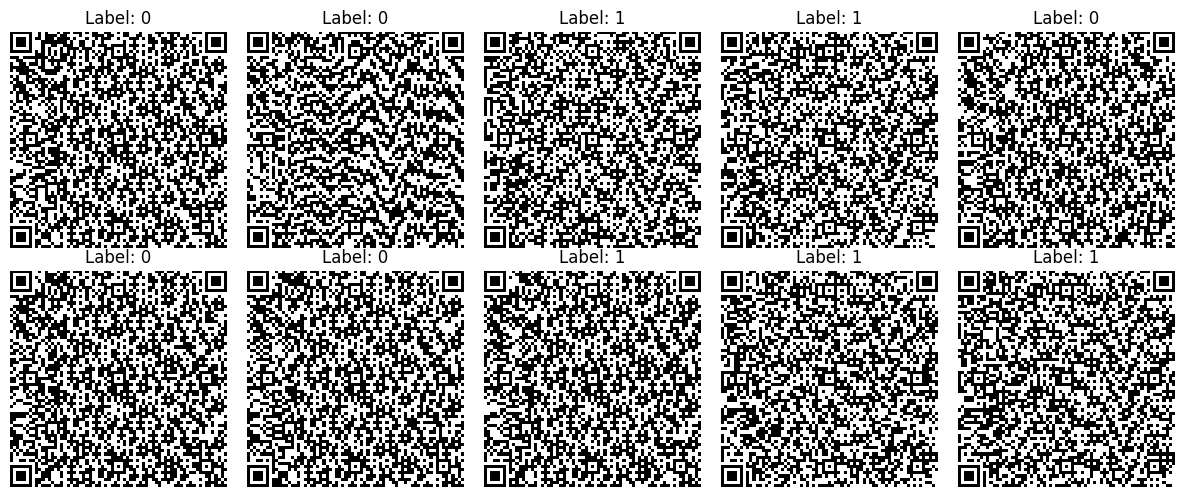

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Select 10 random samples
indices = np.random.choice(len(qr_codes), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(qr_codes[indices[i]], cmap="gray")
    ax.set_title(f"Label: {qr_labels[indices[i]]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

print("QR codes shape:", qr_codes.shape)
print("Labels shape:", qr_labels.shape)

print("QR codes dtype:", qr_codes.dtype)
print("Labels dtype:", qr_labels.dtype)

print("Unique labels:", np.unique(qr_labels, return_counts=True))

QR codes shape: (9987, 69, 69)
Labels shape: (9987,)
QR codes dtype: int16
Labels dtype: int32
Unique labels: (array([0, 1], dtype=int32), array([5005, 4982]))


In [4]:
X = np.asarray(qr_codes)
y = np.asarray(qr_labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9987, 69, 69)
y shape: (9987,)


In [5]:
if X.ndim == 3:
    X = np.expand_dims(X, axis=-1)

print("New X shape:", X.shape)

New X shape: (9987, 69, 69, 1)


In [6]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0
Maximum pixel value: 1


In [7]:
X = X.astype("float32")

if X.max() > 1:
    X = X / 255.0

print("New pixel range:", X.min(), X.max())

New pixel range: 0.0 1.0


In [8]:
y = y.astype("int32")

print("Unique labels:", np.unique(y))
print("Number of samples:", len(y))

Unique labels: [0 1]
Number of samples: 9987


In [9]:
assert set(np.unique(y)).issubset({0, 1}), "Labels must be binary (0 and 1)"

In [10]:
unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label}: {count} samples ({count / len(y) * 100:.2f}%)")

Class 0: 5005 samples (50.12%)
Class 1: 4982 samples (49.88%)


In [219]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=2000,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (7987, 69, 69, 1) (7987,)
Validation: (1000, 69, 69, 1) (1000,)
Testing: (1000, 69, 69, 1) (1000,)


In [205]:
print("Training distribution:")
print(np.unique(y_train, return_counts=True))

print("\nValidation distribution:")
print(np.unique(y_val, return_counts=True))

print("\nTesting distribution:")
print(np.unique(y_test, return_counts=True))

Training distribution:
(array([0, 1], dtype=int32), array([4504, 4483]))

Validation distribution:
(array([0, 1], dtype=int32), array([250, 250]))

Testing distribution:
(array([0, 1], dtype=int32), array([251, 249]))


In [159]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def conv_block(x, filters, dropout=0.0):
    shortcut = x

    # Main path
    x = layers.Conv2D(
        filters, (3, 3),
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        filters, (3, 3),
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)

    # Match shortcut dimensions
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters, (1, 1),
            padding="same",
            use_bias=False
        )(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Residual connection
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    if dropout > 0:
        x = layers.Dropout(dropout)(x)

    return x


inputs = layers.Input(shape=X_train.shape[1:])


# ============================================================
# STEM — preserve QR details
# ============================================================

x = layers.Conv2D(
    32,
    (3, 3),
    padding="same",
    use_bias=False
)(inputs)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)


# ============================================================
# BLOCK 1 — very fine details
# ============================================================

x = conv_block(x, 32, dropout=0.10)

# First downsampling
x = layers.Conv2D(
    64,
    (3, 3),
    strides=2,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)


# ============================================================
# BLOCK 2 — local QR patterns
# ============================================================

x = conv_block(x, 64, dropout=0.10)


# ============================================================
# BLOCK 3 — medium-scale patterns
# ============================================================

x = layers.Conv2D(
    128,
    (3, 3),
    strides=2,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = conv_block(x, 128, dropout=0.15)


# ============================================================
# BLOCK 4 — higher-level QR structure
# ============================================================

x = layers.Conv2D(
    256,
    (3, 3),
    strides=2,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = conv_block(x, 256, dropout=0.20)


# ============================================================
# GLOBAL REPRESENTATION
# ============================================================

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.40)(x)


# Binary classification
outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)


model = keras.Model(inputs, outputs)


model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc")
    ]
)


model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 69, 69, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 69, 69,    │        288 │ input_layer_10[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69, 69,    │        128 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_42       │ (None, 69, 69,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 69, 69,    │      9,216 │ activation_42[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69, 69,    │        128 │ conv2d_43[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_43       │ (None, 69, 69,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 69, 69,    │      9,216 │ activation_43[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69, 69,    │        128 │ conv2d_44[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 69, 69,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation_42[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_44       │ (None, 69, 69,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 69, 69,    │          0 │ activation_44[0]… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 35, 35,    │     18,432 │ dropout_30[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        256 │ conv2d_45[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_45       │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 35, 35,    │     36,864 │ activation_45[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        256 │ conv2d_46[0][0] 

 Total params: 2,026,913 (7.73 MB)

 Trainable params: 2,023,521 (7.72 MB)

 Non-trainable params: 3,392 (13.25 KB)

In [161]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [162]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=20,
    min_lr=1e-7
)

checkpoint = ModelCheckpoint(
    "best_qr_cnn.keras",
    monitor="val_loss",
    save_best_only=True
)

In [165]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.7837 - loss: 0.4678 - precision: 0.8174 - recall: 0.7292 - val_accuracy: 0.7333 - val_loss: 0.4889 - val_precision: 0.8333 - val_recall: 0.6250 - learning_rate: 1.0000e-04
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7902 - loss: 0.4519 - precision: 0.8172 - recall: 0.7463 - val_accuracy: 0.7333 - val_loss: 0.4186 - val_precision: 0.8333 - val_recall: 0.6250 - learning_rate: 1.0000e-04
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8059 - loss: 0.4231 - precision: 0.8321 - recall: 0.7653 - val_accuracy: 0.8000 - val_loss: 0.5130 - val_precision: 0.8571 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8083 - loss: 0.4196 - precision: 0.8246 - recall: 0.7820 - val_accuracy: 0.7333 - val_loss: 0.9348 - val_precision: 1.0000 - val_recall: 0.5000 - learning_rate: 1.0000e-04
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 

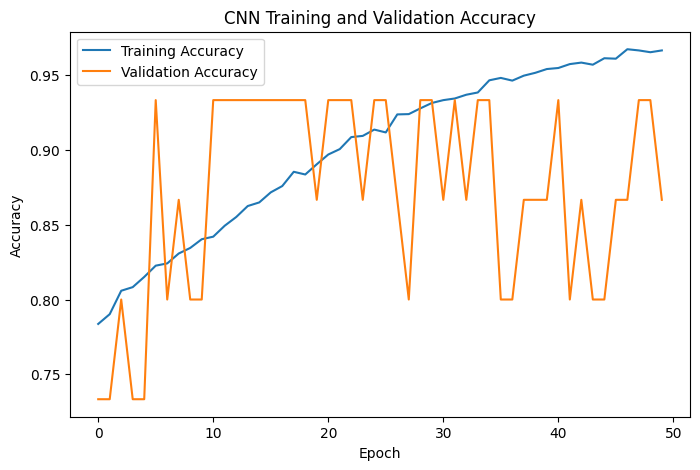

In [220]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()

plt.show()

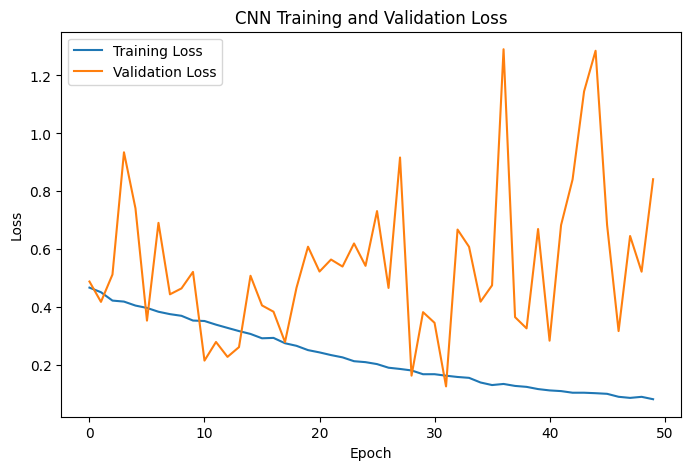

In [221]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()

plt.show()

In [222]:
test_results = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Results:")

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9760 - loss: 0.0727 - precision: 0.9648 - recall: 0.9880

Test Results:
loss: 0.0727
compile_metrics: 0.9760


In [223]:
y_prob = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [224]:
y_pred = (y_prob >= 0.5).astype(int).ravel()

In [225]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Phishing"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Benign     0.9877    0.9641    0.9758       501
    Phishing     0.9648    0.9880    0.9762       499

    accuracy                         0.9760      1000
   macro avg     0.9763    0.9760    0.9760      1000
weighted avg     0.9763    0.9760    0.9760      1000



In [226]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[483  18]
 [  6 493]]


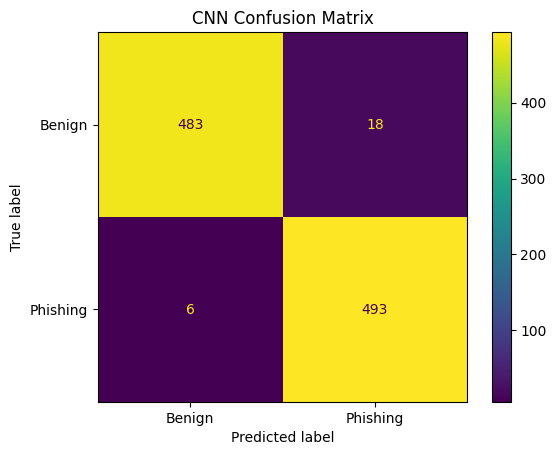

In [227]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Phishing"]
)

disp.plot()

plt.title("CNN Confusion Matrix")
plt.show()

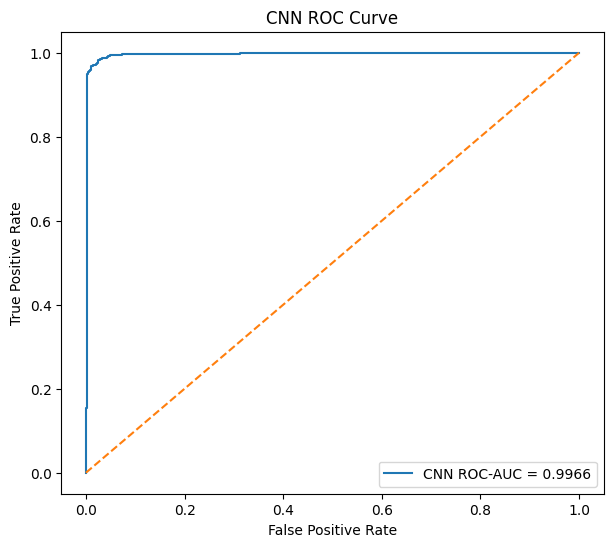

In [228]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob.ravel()
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"CNN ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN ROC Curve")
plt.legend()

plt.show()